# Raça e Deficiência — Base SIAPE

Este notebook mostra o perfil de raça/cor e de deficiência autodeclarados pelos
servidores. Assim como no notebook de carreira, esses campos só estão preenchidos
para uma parte da base (~23%); os demais aparecem como "NI" porque não fazem parte
desse cadastro específico (provavelmente por não terem passado por um processo de
autodeclaração mais recente).

Todos os números são agregados e contagens por categoria — nenhum servidor é
identificado individualmente. Como algumas categorias de deficiência têm poucos
casos, tratamos os números com cautela: são suficientes para dar um panorama, mas
não para conclusões estatísticas fortes.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.viz_style import (
    agrupar_celulas_pequenas,
    aplicar_estilo_global,
    grafico_barra_horizontal,
    resumo_informado,
)

DATA_PATH = Path("../data/raw/DB_SIAPE_processado_20260729_v2.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

aplicar_estilo_global()
TOTAL = len(df)

## Raça/cor

**O que mostra**: a distribuição de raça/cor autodeclarada, entre os servidores com
essa informação preenchida.

23.4% da base (2334 servidores) tem raça/cor autodeclarada registrada.


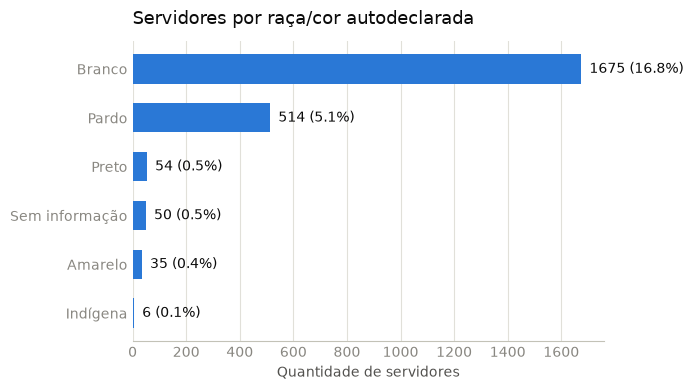

In [2]:
contagem_raca, pct_raca = resumo_informado(df["Raça_Dados pessoais"], TOTAL)
print(f"{pct_raca}% da base ({int(contagem_raca.sum())} servidores) tem raça/cor autodeclarada registrada.")
grafico_barra_horizontal(contagem_raca, TOTAL, "Servidores por raça/cor autodeclarada", figsize=(7, 4))

## Deficiência

**O que mostra**: a distribuição de deficiência autodeclarada, entre os servidores
com essa informação preenchida. A maioria desse grupo declarou não ter deficiência.

**Nota de privacidade**: alguns tipos específicos de deficiência têm poucos casos
(menos de 5 pessoas). Mostrar a contagem exata desses grupos poderia, na prática,
identificar indivíduos — por isso eles são agrupados em "Outras" abaixo.

23.4% da base (2334 servidores) tem informação de deficiência registrada.


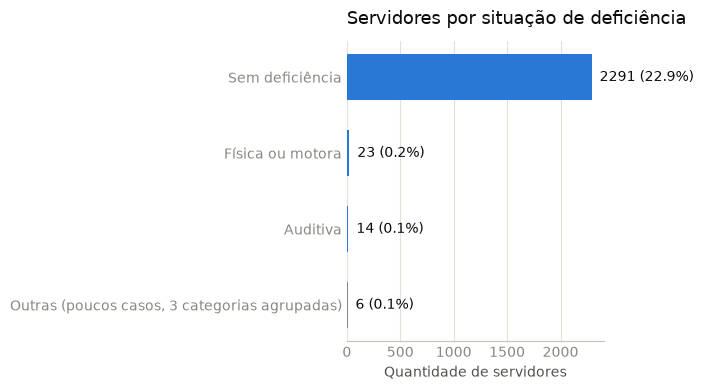

In [3]:
contagem_deficiencia, pct_deficiencia = resumo_informado(df["Deficiência_Dados pessoais"], TOTAL)
print(f"{pct_deficiencia}% da base ({int(contagem_deficiencia.sum())} servidores) tem informação de deficiência registrada.")

contagem_deficiencia_protegida, rotulo_grupo_pequeno = agrupar_celulas_pequenas(contagem_deficiencia, minimo=5)
grafico_barra_horizontal(
    contagem_deficiencia_protegida, TOTAL, "Servidores por situação de deficiência",
    figsize=(7, 4), destacar_neutro=rotulo_grupo_pequeno,
)

## Resumo consolidado

In [4]:
from IPython.display import Markdown, display

pct_com_deficiencia = round(
    (contagem_deficiencia.sum() - contagem_deficiencia.get("Sem deficiência", 0)) / TOTAL * 100, 1
)

resumo_md = f"""
- **{pct_raca}%** da base tem raça/cor autodeclarada; entre esses, a maioria se declara **{contagem_raca.idxmax().lower()}**.
- **{pct_deficiencia}%** da base tem informação de deficiência preenchida; desse grupo, a grande maioria declarou não ter deficiência.
- No total da base, cerca de **{pct_com_deficiencia}%** dos servidores têm alguma deficiência declarada — um número pequeno o suficiente para tratar com cautela, sem detalhar por tipo individual.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
"""

display(Markdown(resumo_md))


- **23.4%** da base tem raça/cor autodeclarada; entre esses, a maioria se declara **branco**.
- **23.4%** da base tem informação de deficiência preenchida; desse grupo, a grande maioria declarou não ter deficiência.
- No total da base, cerca de **0.4%** dos servidores têm alguma deficiência declarada — um número pequeno o suficiente para tratar com cautela, sem detalhar por tipo individual.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
